## <center> Виды операторов SQL

Операторы SQL делятся на:
* **операторы определения данных (Data Definition Language, DDL)** — с их помощью создаются и изменяются объекты в БД (сама БД, таблицы, функции, процедуры, пользователи и т. д.);
* **операторы манипуляции данными (Data Manipulation Language, DML)** — с их помощью проводятся манипуляции с данными в таблицах;
* **операторы определения доступа к данным (Data Control Language, DCL)** — с их помощью, как следует из названия, создаются и изменяются разрешения на определённые операции с объектами в БД;
* **операторы управления транзакциями (Transaction Control Language, TCL)** — с их помощью осуществляется комплекс определённых действий, причём так, что либо все эти действия выполняются успешно, либо ни одно из них не выполняется вообще.
>Мы будем изучать только DML-операторы (для манипуляций с данными), а конкретнее — оператор ```SELECT```, который позволяет выбрать из БД интересующие нас данные.

Работать будем в веб-сервисе:
-  [Metabase](http://sql.skillfactory.ru:3000/)
- [тут будет логин/пароль, если нужно](https://apps.skillfactory.ru/learning/course/course-v1:SkillFactory+DSPRMGU+2023_FEB/block-v1:SkillFactory+DSPRMGU+2023_FEB+type@sequential+block@8e22f42902d04406b48e18c62fed1648/block-v1:SkillFactory+DSPRMGU+2023_FEB+type@vertical+block@50ba77b1a8754ea3a08ffe3288d23252)

## <center> SELECT

SELECT *

FROM sql.kinopoisk

Разбираем запрос

→ Оператор SELECT сообщает СУБД, что вы хотите извлечь из неё данные. SELECT лежит в основе любого SQL-запроса к БД.

→ FROM sql.kinopoisk сообщает, из какой таблицы извлекаются данные. Сначала указывается название схемы, в которой содержится таблица (в нашем случае — это sql), а после точки — название самой таблицы (kinopoisk).

> Звёздочка * указывает, что вы хотите видеть все столбцы этой таблицы.

>Если же вам нужны не все столбцы, а только некоторые, вместо звёздочки перечислите названия всех интересующих вас столбцов через запятую.

>Важно! SQL нечувствителен к регистру, поэтому ключевые слова можно писать хоть строчными, хоть прописными буквами: SELECT, select или SeLeCt.

Независимо от того, в каком порядке представлены столбцы в таблице, в запросе вы можете указывать их в любой очерёдности.

> Порядок столбцов в выводе будет совпадать с их расположением после оператора SELECT.

Допустим, вы хотите написать запрос, аналогичный запросу из задания, только вместо года выхода фильма, вам нужен его «возраст» на 2020 год.

В таком случае наш запрос будет выглядеть так:

``` sql
SELECT /*выбор столбцов*/
    movie_title, /*столбец movie_title*/
    2020 - year, /*столбец, каждое из значений которого ровно разнице 2020 и соответствующего значения столбца year*/
    rating /*столбец rating*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
```

---

Напишите запрос, который выведет из таблицы kinopoisk следующие столбцы:

имя режиссёра (director),
название фильма (movie_title),
разница между максимально возможным рейтингом (10) и рейтингом этого фильма.

```sql
SELECT
  director,
  movie_title,
  10 - rating
From sql.kinopoisk
```

---
Чтобы переименовать столбец, используем ключевое слово ```AS``` и поставим после него новое имя difference. Можем повторить этот процесс для каждого столбца.

```sql
SELECT /*выбрать столбцы*/
    director, /*столбец director*/
    movie_title, /*столбец movie_title*/
    10 - rating AS difference /*столбец, значения в котором равны разнице 10 и каждого соответствующего значения столбца rating; присвоить столбцу алиас difference*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
```

Новое имя является просто псевдонимом, или ***алиасом***, — оно временное и не меняет реального имени столбца в базе данных. Алиас влияет только на то, как столбец отображается в выводе конкретного запроса.

> ***Алиас*** — имя, назначенное источнику данных в запросе при использовании выражения в качестве источника данных или для упрощения ввода и прочтения инструкции SQL.
>
Алиасом может быть как одно слово, так и несколько, а его написание — как латиницей, так и кириллицей.

> Обратите внимание! Если в алиасе используется кириллица или пробелы, необходимо заключать его в двойные кавычки: 10 - rating AS "разница" или movie_title AS "Movie Title".

---
## Простые операции с данными

Со столбцами, которые содержат числовые данные, можно проводить арифметические операции:
* сложение с помощью + ;
* вычитание с помощью - (этот тип операции вы уже проводили, когда определяли «возраст» фильма);
* умножение с помощью * ;
* деление с помощью / ;
* получение остатка от деления с помощью % .

> Важно! Если и числитель, и знаменатель — целые числа, результат деления также будет целочисленным, то есть этот оператор произведёт деление нацело.

[Официальная документация по математическим операциям](https://postgrespro.ru/docs/postgresql/11/functions-math)

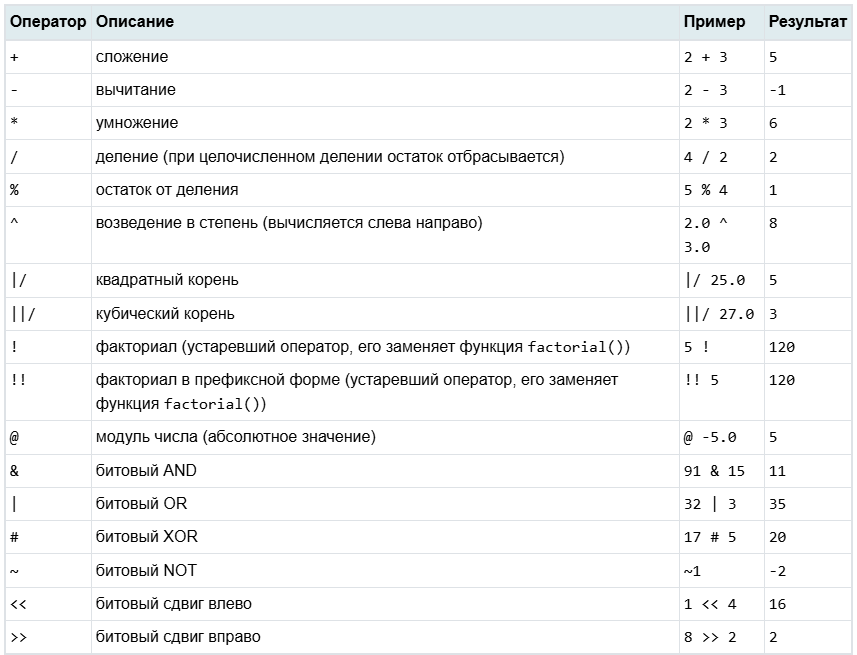

Задание 1.3 (External resource)
Напишите запрос, который выведет столбцы с именем режиссёра, названием фильма, рейтингом по 100-балльной шкале (столбец rating_100). Рейтинг по 100-балльной шкале определите как оценку по 10-балльной, умноженную на 10.

```sql
SELECT
  director,
  movie_title,
  10 * rating AS rating_100 
FROM sql.kinopoisk
```

Давайте выведем для каждого фильма результат деления года его выпуска на рейтинг (что бы это ни значило :)

```sql
SELECT
    movie_title,
    year / rating
FROM sql.kinopoisk
```

---

## <center> Фильтруем строки

### Where
Но как быть, если мы хотим видеть не все строки, а только некоторые из них?

В таком случае нам пригодится ключевое слово ```WHERE```.

Получим для примера всю информации о фильме, занимающем первую позицию.
```sql
SELECT * /*выбор всех столбцов*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE position = 1 /*с позицией 1*/
```

> Напишите запрос, чтобы вывести все столбцы для фильмов, которые вышли в прокат в 1999 году.

```sql
SELECT *
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE year = 1999
```

В запросах выше мы использовали знак равно (=), но никто не запретит нам использовать и условные операторы.

Вы можете применять знаки < (меньше), <= (меньше или равно), > (больше), >= (больше или равно).

> Посмотрим на фильмы, которые вышли в прокат до 1984 года

```sql
SELECT /*выбор всех полей*/
    position, /*столбец position*/
    movie_title, /*столбец movie_title*/
    year, /*столбец year*/
    director /*столбец director*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE year < 1984 /*при условии, что год создания меньше 1984*/
```

При этом вы можете комбинировать вывод конкретных столбцов и условия.

Ещё один условный оператор, который нам доступен, — знак неравенства != или <>.

>Выведем все столбцы для всех фильмов, кроме тех, что были сняты в 2000 году.
```sql
SELECT * /*выбор всех полей*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE year <> 2000 /*если год создания не 2000*/
```

# AND и OR

Допустим, одного условия нам мало.

В таком случае мы можем комбинировать их с помощью AND и OR

>Типичная ситуация: выбираем фильм на вечер. Мы хотим, чтобы фильм был относительно современным и с высоким рейтингом.
```sql
SELECT * /*выбор всех полей*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE year >= 2000 /*при условии, что год создания больше или равен 2000*/
AND rating >= 8 /*и с рейтингом от 8 и выше*/
```

> Теперь вы хотите получить информацию о фильмах, которые вышли между 1975 и 1985 годами включительно. Можно воспользоваться следующим запросом:
```sql
SELECT * /*выбор всех полей*/
FROM sql.kinopoisk /*из таблицы sqk.kinopoisk*/
WHERE year >= 1975 /*при условии, что год создания 1975 и позднее*/
    AND year <= 1985 /*и ранее 1985*/
```

# Between

Мы только что отправили запрос для вывода данных по фильмам с 1975 и 1985 годы. Цели мы достигли, но сама запись оставляет желать лучшего.

Можем оптимизировать её, сделав более элегантной с помощью BETWEEN:
```sql
SELECT * /*выбор всех полей*/
FROM sql.kinopoisk /*из таблиц sql.kinopoisk*/
WHERE year BETWEEN 1975 AND 1985 /*при условии, что год создания лежит в промежутке между 1975 и 1985*/
```


> Напишите запрос, который выведет столбцы с именем режиссёра и названием фильмов, у которых рейтинг больше или равен 8.5. Не забудьте, что в качестве десятичного разделителя используется точка.
```sql
SELECT 
director,
movie_title
FROM sql.kinopoisk /*из таблиц sql.kinopoisk*/
WHERE rating >= 8.5
```

# NOT

В дополнение к другим операторам можно использовать ключевое слово NOT — оно «переворачивает» следующий за ним оператор.

>Выведем все фильмы, кроме тех, что вышли с 1965 по 1980 годы.
```sql
SELECT * /*выбор всех полей*/
FROM sql.kinopoisk /*из таблицы sql.kinopoisk*/
WHERE year NOT BETWEEN 1965 AND 1980 /*при условии, что год создания не лежит в промежутке между 1965 и 1980*/
```

Если включаете в запрос несколько условий AND и OR, используйте скобки: они работают так же, как и с арифметическими операциями.

*Важно! Условия в скобках имеют больший приоритет*.